In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

sys.path.append('src')

In [2]:
import scanpy as sc

In [3]:
adata = sc.read_h5ad("../dsa/notebooks/synthetic_eval/synthetic_spatial_adata.h5ad")
adata.var.index = adata.var['gene_name-new']
domains_key = "region"
labels_key = 'cell_type'

In [4]:
# adata = sc.read(
#     f"../../data/crc_wt_cosmx/crc_242.h5ad",
#     backup_url=f"https://zenodo.org/records/15574384/files/242.h5ad?download=1"
# )
# # adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
# adata.obs_names_make_unique()

# label_to_coarse = {
#     "epi1": "Epithelial",
#     "epi2": "Epithelial",
#     "epi3": "Epithelial",
#     "epi4": "Epithelial",
    
#     "fib1": "Fibroblast",
#     "fib2": "Fibroblast",
    
#     "EC": "Endothelial",
#     "SMC": "Smooth_muscle",
    
#     "BC": "B_cell",
#     "PC_IgA": "Plasma_cell",
#     "PC_IgG": "Plasma_cell",
#     "PC_IgM": "Plasma_cell",
    
#     "TC": "T_cell",
    
#     "mye1": "Myeloid",
#     "mye2": "Myeloid",
    
#     "mast": "Mast_cell",
# }

# adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
# labels_key = 'coarse_type'
# domains_key = 'typ'
# adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
# adata = adata[~adata.obs[labels_key].isna()]
# adata.obs[labels_key] = adata.obs[labels_key].astype('category')
# adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
# adata.layers['counts'] = adata.X.copy()
# sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=3000, subset=True)

In [5]:
adata.X

array([[4.0546355e-01, 1.3191858e-02, 5.7775020e-03, ..., 5.9586668e-01,
        3.1653152e+00, 1.6032119e-01],
       [3.0557573e-01, 8.0697797e-03, 1.0863479e-02, ..., 6.6156961e-02,
        3.4897977e-01, 1.3320860e-01],
       [4.1519508e+00, 1.3122945e+00, 1.4071622e-01, ..., 2.2332193e+01,
        6.9882057e+01, 7.2697718e-03],
       ...,
       [2.4183877e+00, 2.4768515e-01, 6.0280837e-02, ..., 6.2022386e+00,
        2.7243963e+01, 2.2268949e-02],
       [6.9999164e-01, 5.6562554e-02, 2.2703696e-02, ..., 1.7475737e+01,
        5.3366581e+01, 1.2229774e-02],
       [6.0382867e-01, 2.2771050e-01, 9.6838303e-02, ..., 6.5686679e-01,
        5.6160693e+00, 5.9514619e-02]], dtype=float32)

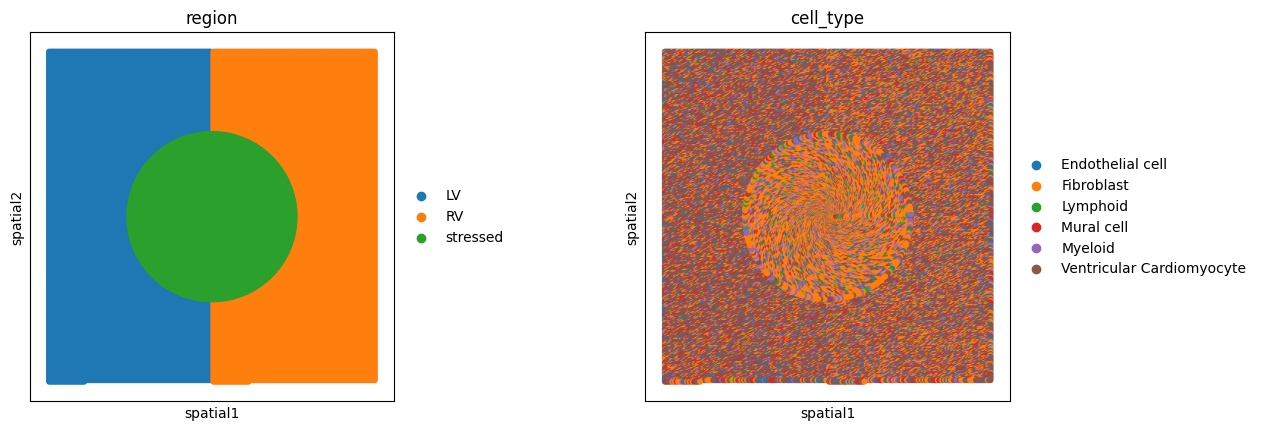

In [6]:
sc.pl.spatial(adata, color=[domains_key, labels_key], spot_size=20)

In [7]:
from anndata import AnnData
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

from src.cellina._spatial_utils import weighted_pseudobulks, spatial_neighbors

In [8]:
n_neighbors = 20
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [9]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'][:,0].toarray().astype(np.float32)

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.obsm['spatial_x'] = adata.obsp['spatial_connectivities'] @ adata.X

In [11]:
# NOTE: inefficient and issues with explosion of feature counts
# weighted_pseudobulks(
#     adata,
#     sp=adata.obsp['spatial_connectivities'],
#     groupby=labels_key
# )

In [12]:

# ndata = AnnData(adata.obsm['spatial_x'], obs=adata.obs, var=adata.uns['_spatial_var'], obsm=adata.obsm)
# ndata.var['average'] = ndata.X.mean(axis=0)
# ndata.var['std'] = ndata.X.std(axis=0)
# ndata.var['cv'] = ndata.var['std'] / ndata.var['average']

In [13]:
# ndata.var.set_index(0, inplace=True)

In [14]:
# ndata.var.sort_values('cv', ascending=False, key=abs).head(5)
# # TODO: need to move away from uniform representation of space

In [15]:
# sc.pl.spatial(ndata, color=['Ventricular Cardiomyocyte_CLDN5'], spot_size=5)

In [16]:
# top_genes_idx = np.abs(np.argsort(ndata.var['cv']))[-1000:]
# adata.obsm['spatial_x'] = adata.obsm['spatial_x'][:, top_genes_idx]

In [17]:
adata.obsm['spatial_x'].shape

(49800, 3000)

In [39]:
from cellina import CellinaModel

In [40]:
CellinaModel.setup_anndata(adata,
                           batch_key=None,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts',
                           spatial_connectivities_key='spatial_connectivities')
model = CellinaModel(adata, n_latent=20, classifier_lambda=1e5, discriminator_lambda=1e5, condition_on_intrinsic=False, link_prediction_weight=10e5)

INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


In [41]:
model.train(max_epochs=50,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=10,
            early_stopping_monitor='validation_loss', # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            # default_root_dir='scvi_log/',
            plan_kwargs={'lr': 0.0001,
                         'weight_decay': 0.0001,
                         'normalize_losses': False,
                        #  "scale_adversarial_loss": "normalized"
                         },
            enable_checkpointing=True,
            # callbacks=[
            #     SaveCheckpoint(monitor="validation_loss",
            #                    load_best_on_end=True,
            #                    dirpath=f'scvi_log/synthetic/',
            #                    filename='test1'),
            # ],
            batch_size=2048,
            devices=[1]
            )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


Training:   0%|          | 0/50 [00:00<?, ?it/s]

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 29448. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 28896. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 15541. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py

In [42]:
list(model.history_.keys())

['validation_loss',
 'elbo_validation',
 'reconstruction_loss_validation',
 'kl_local_validation',
 'kl_global_validation',
 'vae_loss_validation',
 'classifier_loss_raw_validation',
 'classifier_loss_validation',
 'classifier_accuracy_validation',
 'fool_loss_raw_validation',
 'fool_loss_validation',
 'fool_accuracy_validation',
 'edge_prediction_loss_validation',
 'discriminator_loss_validation',
 'discriminator_accuracy_validation',
 'ema_vae_init',
 'ema_clf_init',
 'ema_fool_init',
 'discriminator_loss_train',
 'discriminator_accuracy_train',
 'train_loss',
 'elbo_train',
 'reconstruction_loss_train',
 'kl_local_train',
 'kl_global_train',
 'vae_loss_train',
 'classifier_loss_raw_train',
 'classifier_loss_train',
 'classifier_accuracy_train',
 'fool_loss_raw_train',
 'fool_loss_train',
 'fool_accuracy_train',
 'edge_prediction_loss_train']

<Axes: xlabel='epoch'>

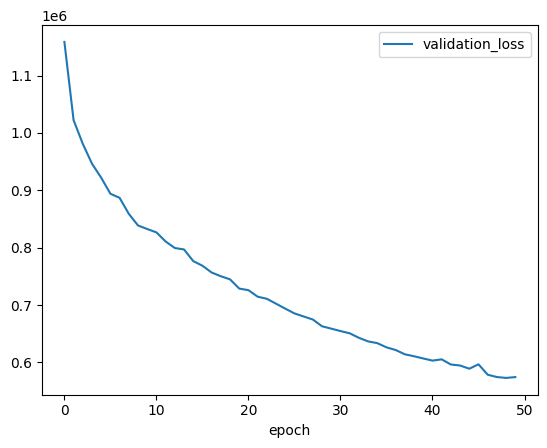

In [43]:
model.history_['validation_loss'].plot()

<Axes: xlabel='epoch'>

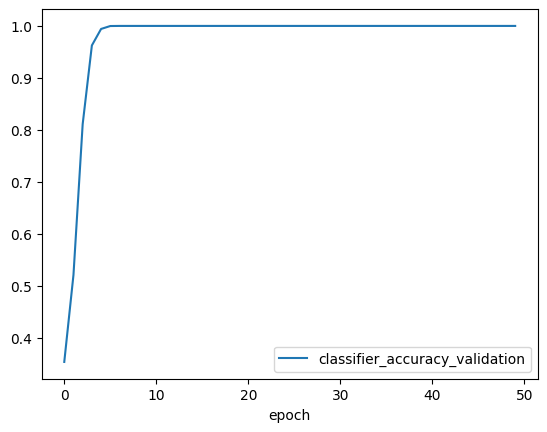

In [44]:
model.history_['classifier_accuracy_validation'].plot()

<Axes: xlabel='epoch'>

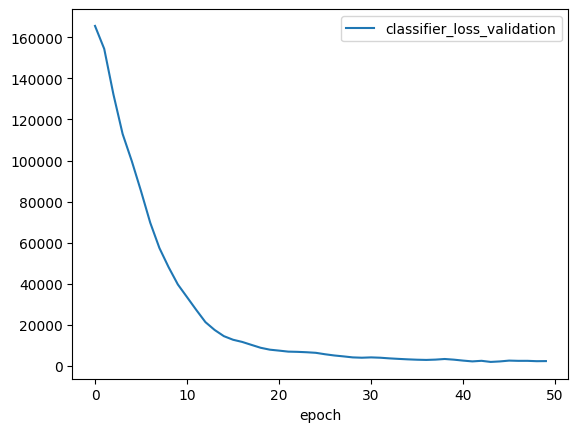

In [45]:
model.history_['classifier_loss_validation'].plot()

<Axes: xlabel='epoch'>

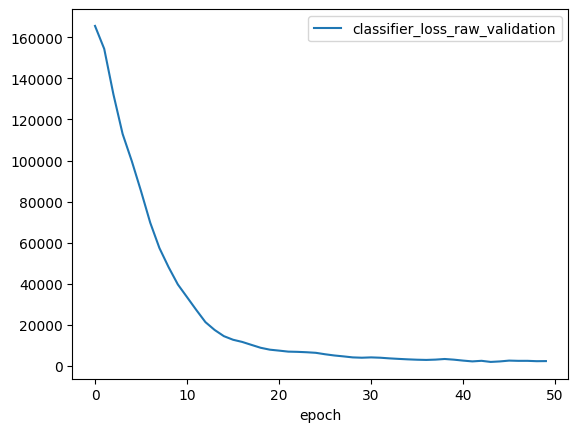

In [46]:
model.history_['classifier_loss_raw_validation'].plot()

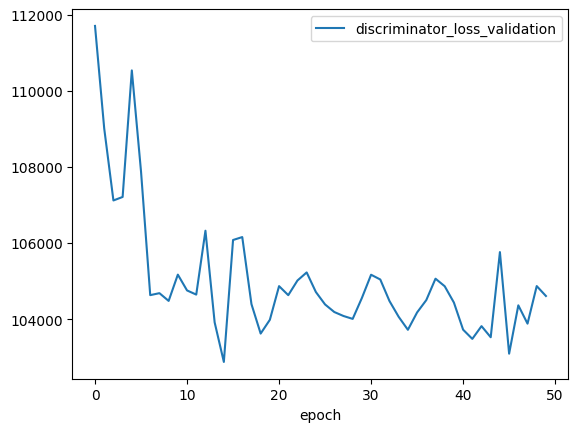

In [47]:
if 'discriminator_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['discriminator_loss_validation'].plot()

In [48]:
model.history_.keys()

dict_keys(['validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'discriminator_loss_validation', 'discriminator_accuracy_validation', 'ema_vae_init', 'ema_clf_init', 'ema_fool_init', 'discriminator_loss_train', 'discriminator_accuracy_train', 'train_loss', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train'])

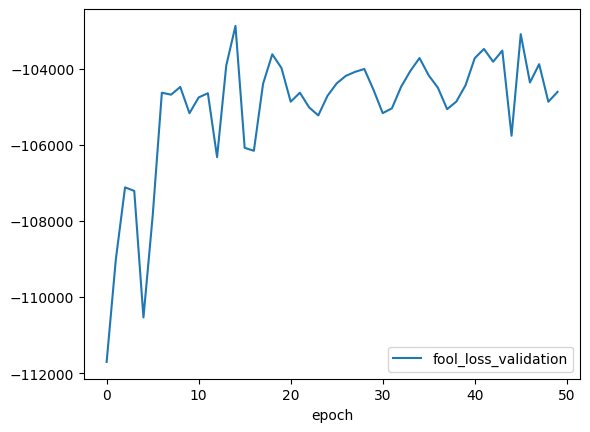

In [49]:
if 'fool_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['fool_loss_validation'].plot()

<Axes: xlabel='epoch'>

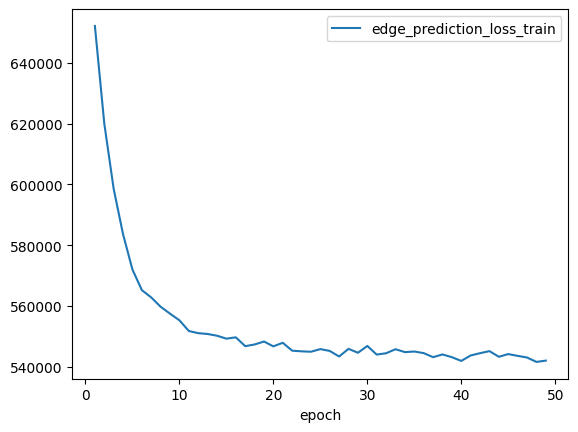

In [51]:
model.history_['edge_prediction_loss_train'].plot()

In [52]:
adata.obsm['z'] = model.get_latent_representation(latent_key='z')

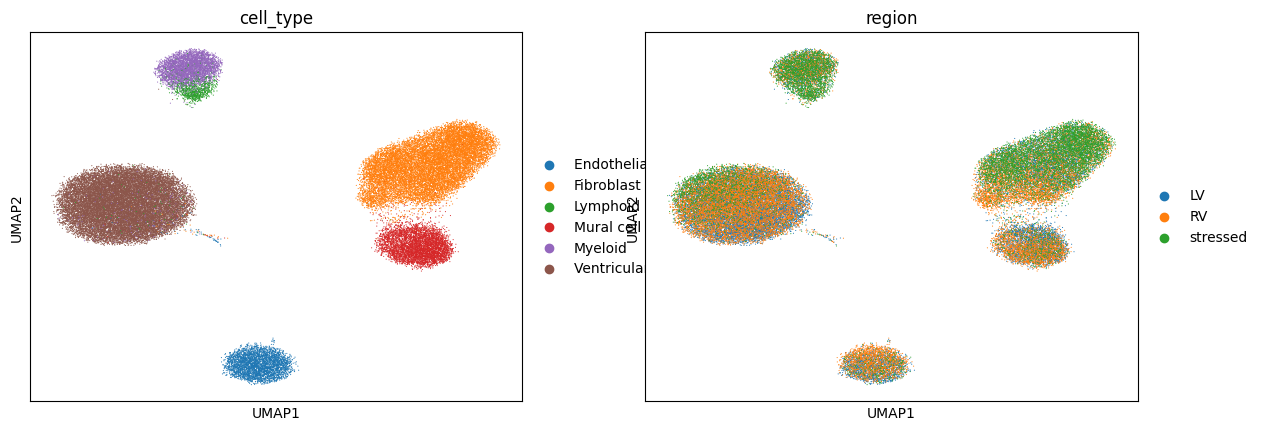

In [53]:
sc.pp.neighbors(adata, use_rep='z')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[labels_key, domains_key])

In [54]:
adata.obsm['z'].max()

np.float32(5.782549)

In [55]:
adata.obsm['s'] = model.get_latent_representation(latent_key='s')

In [56]:
adata.obsm['s'].max()

np.float32(7.770782)

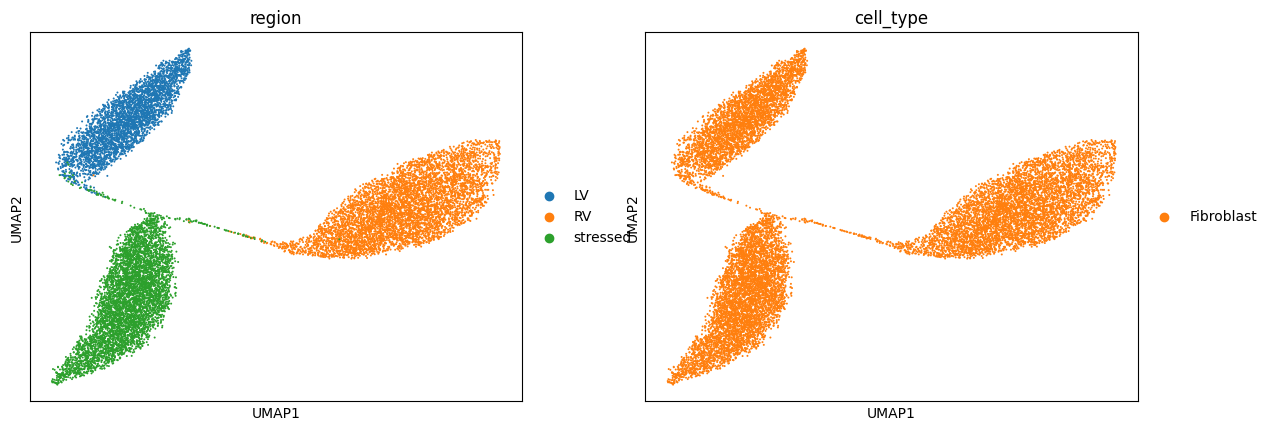

In [57]:
fib_adata = adata[adata.obs[labels_key]=='Fibroblast']
sc.pp.neighbors(fib_adata, use_rep='s')
sc.tl.umap(fib_adata)
sc.pl.umap(fib_adata, color=[domains_key, labels_key])

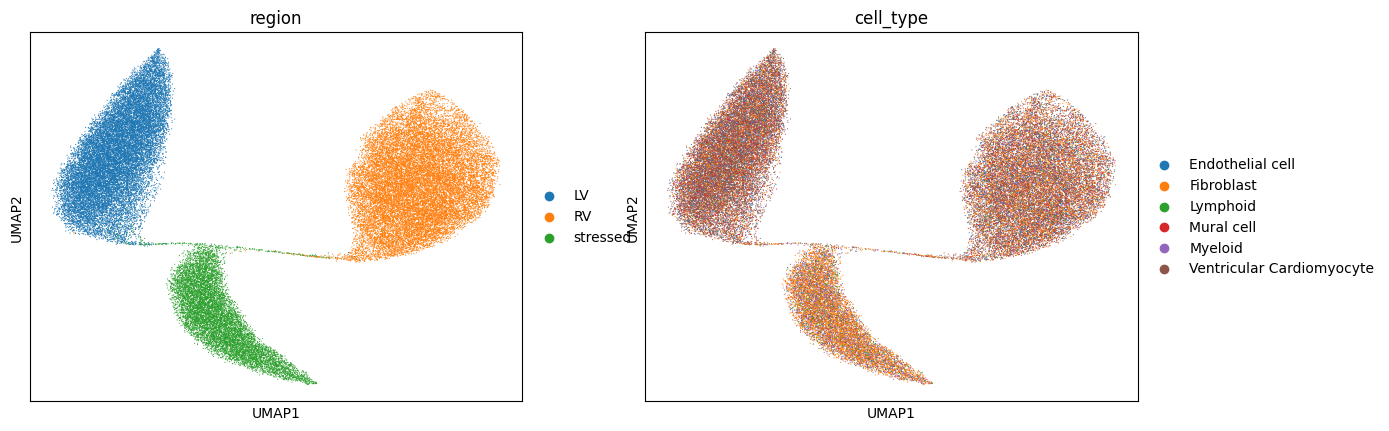

In [58]:
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[domains_key, labels_key])